# LOCO Validation — Immunogenicity Calibrator (Issue #547)

Goal: validate the KDE-based immunogenicity calibrator (`PresentationCalibrator`) via leave-one-cohort-out (LOCO) cross-validation.

**Key caveat:** none of the cohorts (NCI, TESLA, HiTIDE, IMPROVE) is a splice-junction neoepitope cohort — all four are SNV point-mutation datasets. LOCO therefore tests cross-lab/assay transferability as the best available stand-in, not point-mutation → splice transfer directly. **LOCO success ≠ splice validation.**

## Method recap

**Goal.** Turn a raw MHC **presentation** score (`genotype_presentation_score` — the genotype-level presentation likelihood from MHCflurry's `Class1PresentationPredictor`) into a `calibrated_immunogenicity_log_odds`: a monotone, interpretable score anchored to the true immunogenicity base rate. Reimplemented from NeoGuider (Wei et al., *Genome Medicine* 2026); the centered-isotonic step follows Oron & Flournoy (2017).

**Calibration pipeline** (`PresentationCalibrator.fit`):

1. **KDE of class densities.** Estimate the density of `genotype_presentation_score` separately for immunogenic (positive) and non-immunogenic (negative) peptides. *Adaptive* (Abramson sample-point, variable-bandwidth ∝ 1/√pilot-density) is the default; *fixed* (Scott's-rule) is the baseline we benchmark against.
2. **Density ratio + prior.** `log-odds(score) = log d_pos(score) − log d_neg(score) + prior`, with `prior = log(n_pos_true / n_neg_true)` from the **true pre-subsample counts** — so the absolute log-odds stays unbiased despite negatives being subsampled.
3. **Isotonic regression.** Enforce monotonicity (higher presentation ⇒ higher immunogenicity log-odds) via weighted PAVA isotonic regression; weights are local data support (true-count-scaled densities).
4. **Centered isotonic regression** (Oron & Flournoy 2017). Collapse each flat isotonic level-set to its weight-centroid knot → a smooth, non-stepped interpolant. The Python port is validated against the R [`cir`](https://cran.r-project.org/web/packages/cir/cir.pdf) package (see `tests/`).

**Validation metrics:**

- **Reliability curve with Wilson CIs.** Bin predicted log-odds; plot the (reweighted) observed positive rate per bin against the prediction. CI width uses the **Kish effective sample size** `n_eff = (Σw)² / Σ(w²)` — the large negative-reweighting weights inflate Σw thousands-fold while `n_eff` stays near the *sampled* n, so a naïve weighted-n would understate variance (~5×) and make the curve look more precise than it is.
- **Monotonicity check.** Fraction of consecutive reliability bins where the observed rate is non-decreasing — a directly-observable calibration sanity check on top of the structural monotonicity the isotonic step guarantees.
- **AUPRC + prevalence-relative lift.** Weighted area under the precision–recall curve, read as **lift = AUPRC / prevalence** (a random classifier's AUPRC equals the cohort's true positive prevalence). Absolute AUPRC is not comparable across cohorts whose prevalence spans 0.0002–0.05.

**Hold-out design — LOCO.** Leave-one-cohort-out: fit on three cohorts, test on the held-out fourth, rotate through all four. This measures **cross-lab / cross-assay** generalization (per the [#592](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/592) decision) — a stricter, more honest test than within-cohort k-fold (also computed here, as the *shift-gap* contrast). **Caveat:** all four cohorts (NCI, TESLA, HiTIDE, IMPROVE) are SNV point-mutation neoantigens, so LOCO is *not* a direct test of point-mutation → splice-junction transfer. **LOCO success ≠ splice validation.**

Load libraries, data, and true-count table; print per-cohort label distribution with **positive (immunogenic) frequencies** for both the subsample and the true pre-subsample counts. The subsample `pos_freq` is inflated (negatives are subsampled); the true `pos_freq` is the real immunogenicity prevalence and equals the AUPRC random baseline used in the lift table.

In [1]:
import sys, os
sys.path.insert(0, "/Users/jin-holee/dev/GitHub/Jin-HoMLee/splice-neoepitope-pipeline-scientist/research/experiments/issue_547_immunogenicity_calibration")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings("ignore")

from calibrator import PresentationCalibrator

BASE = "/Users/jin-holee/dev/GitHub/Jin-HoMLee/splice-neoepitope-pipeline-scientist/research/experiments/issue_547_immunogenicity_calibration"
df = pd.read_parquet(os.path.join(BASE, "outputs/scored_cohort_subsample.parquet"))
tc = pd.read_csv(os.path.join(BASE, "outputs/scored_cohort_subsample.parquet.true_counts.csv"))

# Build true-count dicts
true_pos = tc[tc.label==1].set_index("cohort")["count"].to_dict()
true_neg = tc[tc.label==0].set_index("cohort")["count"].to_dict()

COHORTS = ["NCI", "TESLA", "HiTIDE", "IMPROVE"]

def _cohort_freq_table(pos_dict, neg_dict):
    """One row per cohort: pos/neg counts, total, and pos_freq = positive (immunogenic) rate."""
    rows = []
    for c in COHORTS:
        p, n = int(pos_dict.get(c, 0)), int(neg_dict.get(c, 0))
        tot = p + n
        rows.append({"cohort": c, "pos": p, "neg": n, "total": tot,
                     "pos_freq": p / tot if tot else np.nan})
    return pd.DataFrame(rows)

# Subsample pos/neg per cohort (all positives kept; negatives subsampled)
_sub = df.groupby(["cohort", "label"]).size().unstack(fill_value=0)
sub_pos = _sub.get(1, pd.Series(dtype=int)).to_dict()
sub_neg = _sub.get(0, pd.Series(dtype=int)).to_dict()

sub_freq = _cohort_freq_table(sub_pos, sub_neg)
true_freq = _cohort_freq_table(true_pos, true_neg)

_fmt = {"pos_freq": "{:.6f}".format}
print("Per-cohort counts (subsample) — pos_freq = positive (immunogenic) rate in the subsample (inflated by negative subsampling):")
print(sub_freq.to_string(index=False, formatters=_fmt))
print("\nTrue counts (pre-subsample) — pos_freq = true immunogenicity prevalence (= the AUPRC random baseline used in the lift table below):")
print(true_freq.to_string(index=False, formatters=_fmt))

Per-cohort counts (subsample) — pos_freq = positive (immunogenic) rate in the subsample (inflated by negative subsampling):
 cohort  pos   neg  total pos_freq
    NCI  103 47809  47912 0.002150
  TESLA   34    80    114 0.298246
 HiTIDE   41   173    214 0.191589
IMPROVE  467  1938   2405 0.194179

True counts (pre-subsample) — pos_freq = true immunogenicity prevalence (= the AUPRC random baseline used in the lift table below):
 cohort  pos    neg  total pos_freq
    NCI  103 420683 420786 0.000245
  TESLA   34    702    736 0.046196
 HiTIDE   41   1522   1563 0.026232
IMPROVE  467  17053  17520 0.026655


### Method, visualized

The schematics below walk through the calibration pipeline end-to-end, reused from the **NeoGuider tool-primer deck** ([Issue #258](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/258) — `research/evals/issue_258_neoguider/figures/`, regeneratable via that folder's `_regenerate_figures.py`). They are **illustrative** — synthetic example data, *not* our fitted cohorts — included as a visual companion to the Method recap above. The single-feature path shown is exactly what `PresentationCalibrator` implements; NeoGuider's downstream *multi-feature* logistic combination is out of scope for [#708](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/708). (Cross-experiment read — documented under "Cross-experiment deps" in this folder's README.)

**Step 1 — class-conditional densities.** KDE of `presentation_score` for immunogenic vs non-immunogenic peptides; the overlap zone is where calibration earns its keep.  
*(illustrative schematic — source: NeoGuider eval, Issue #258)*

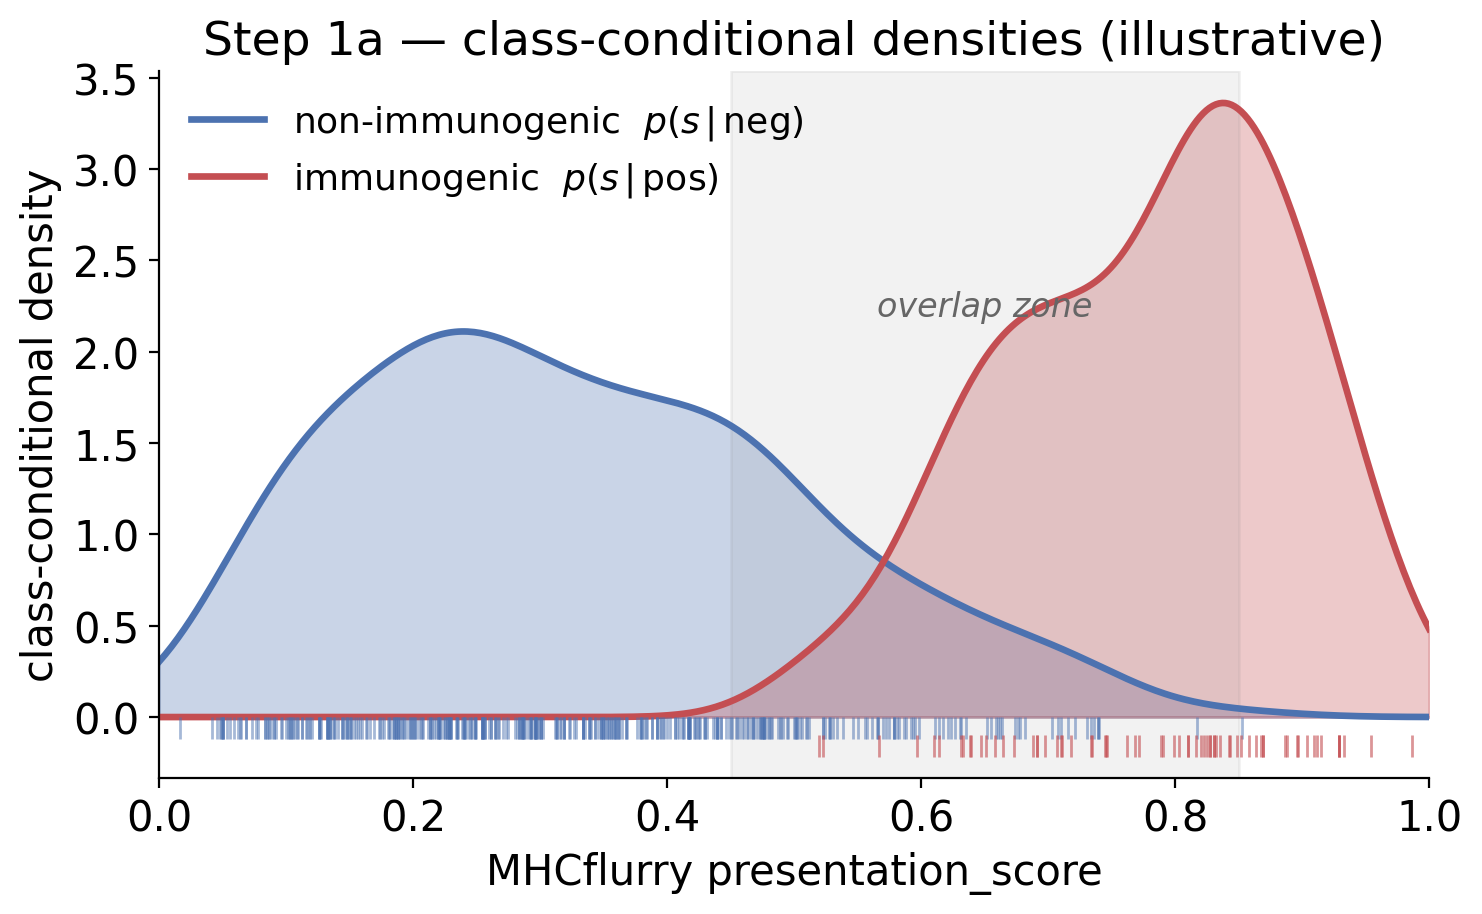

**Step 2 (ratio) — log density-ratio.** `log[p(s|pos)/p(s|neg)]` is the raw, pre-prior log-odds of immunogenicity at each score.  
*(illustrative schematic — source: NeoGuider eval, Issue #258)*

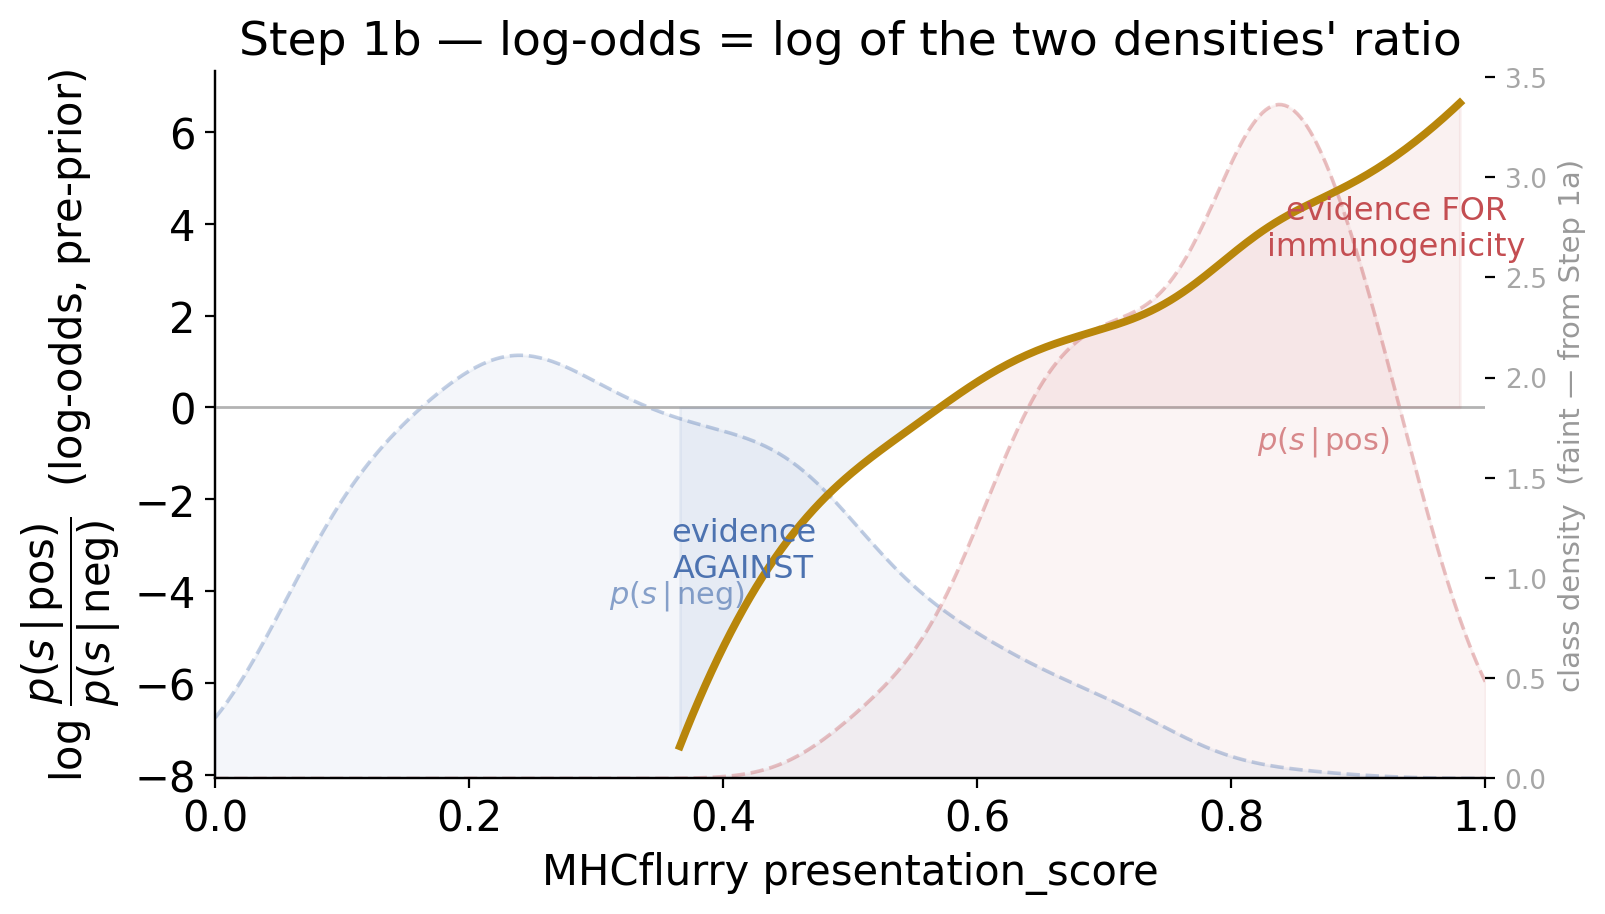

**Step 2 (prior) — base-rate shift.** The true-base-rate prior log-odds shifts the whole curve by a constant; it never bends it. Our artifact's prior = log(645/439960) ≈ −6.53.  
*(illustrative schematic — source: NeoGuider eval, Issue #258)*

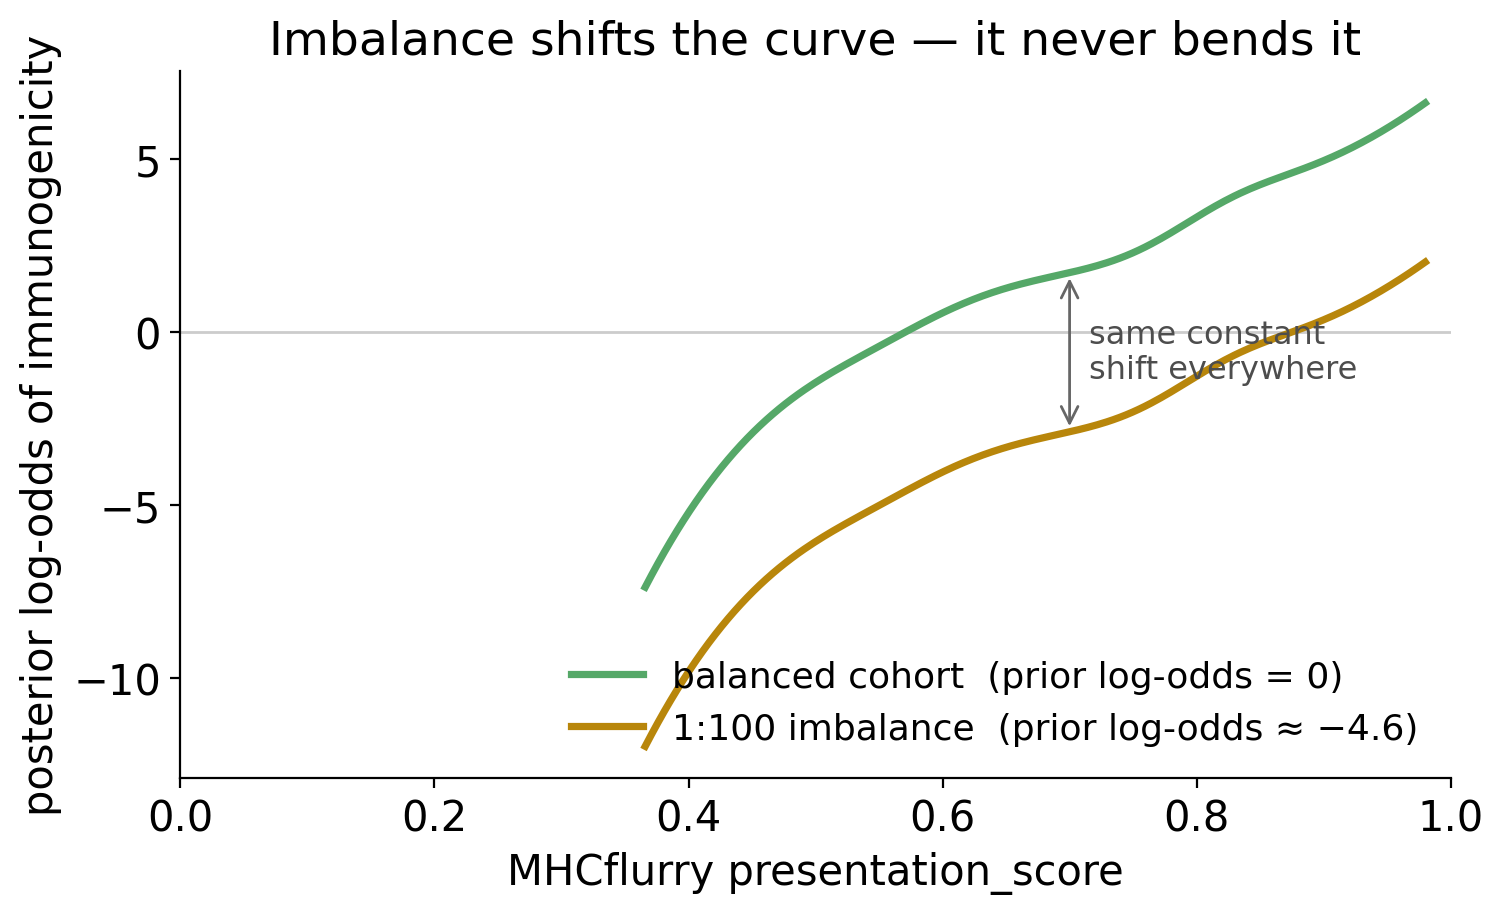

**Steps 3–4 — isotonic → centered isotonic.** PAVA isotonic gives a monotone staircase; centered isotonic collapses each flat level-set to its weight-centroid and interpolates (validated vs R `cir`).  
*(illustrative schematic — source: NeoGuider eval, Issue #258)*

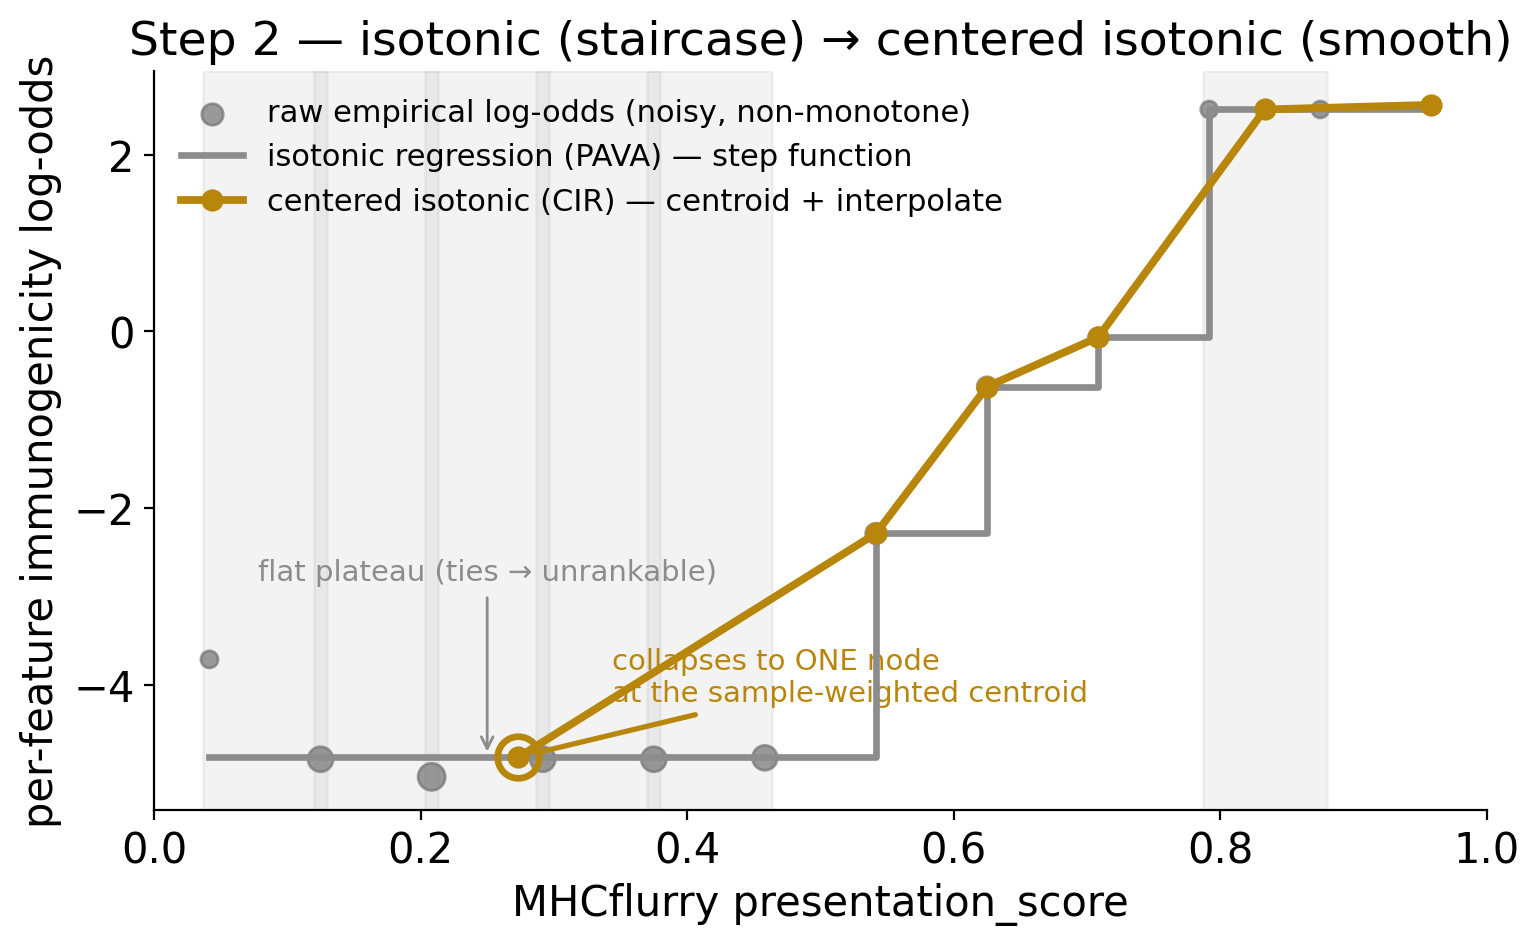

**Inference (`transform`).** A new peptide's `presentation_score` is looked up on the fitted curve to read off its `calibrated_immunogenicity_log_odds`.  
*(illustrative schematic — source: NeoGuider eval, Issue #258)*

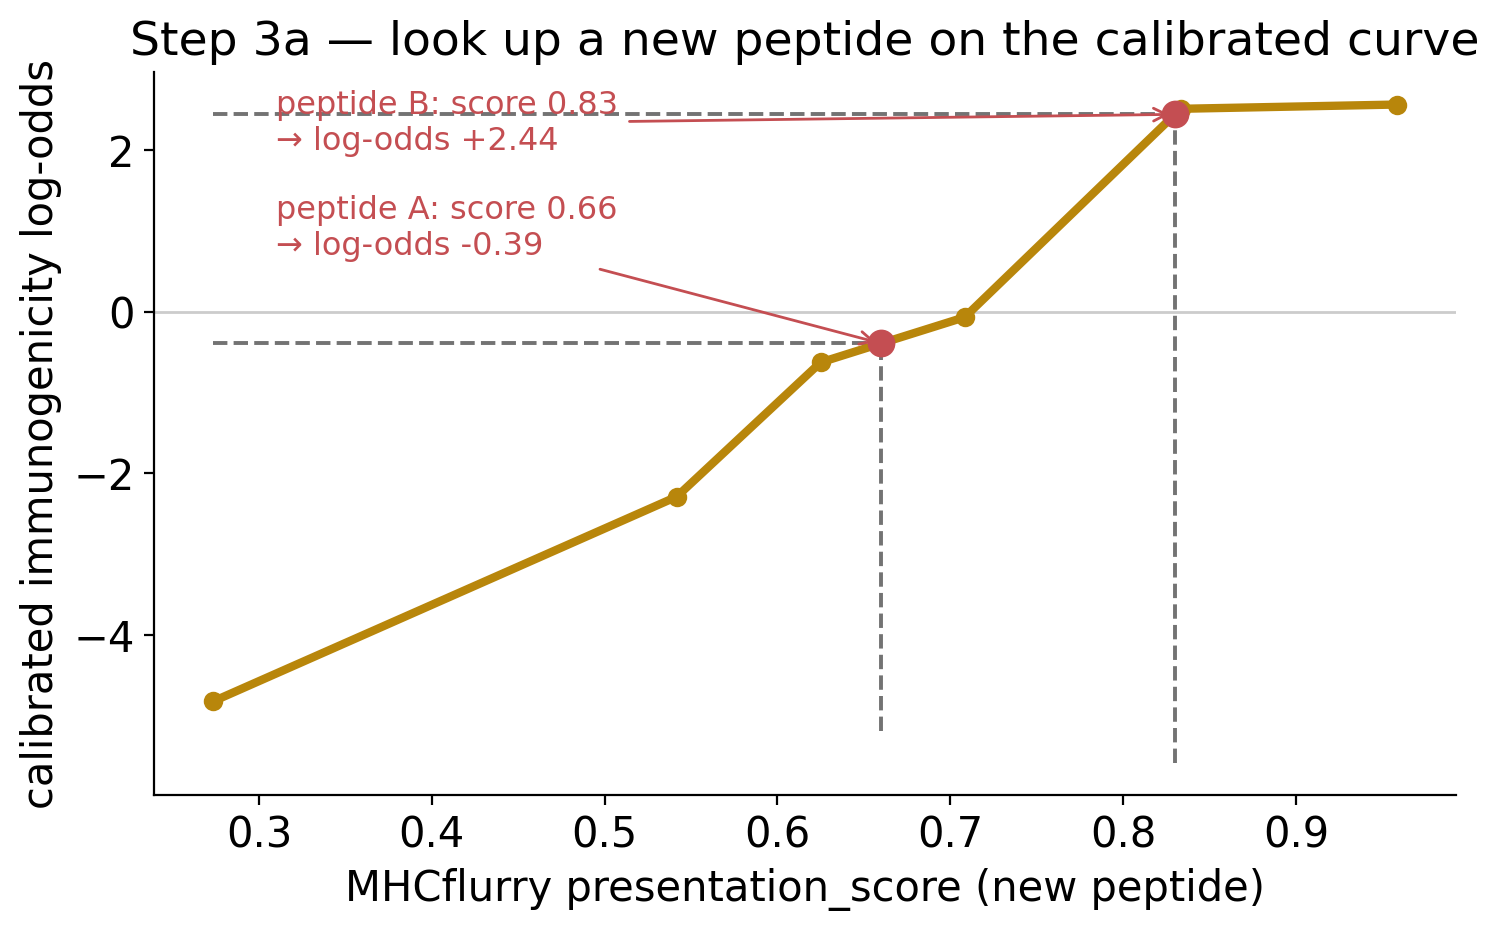

In [2]:
# Reused method schematics from the NeoGuider tool-primer deck (Issue #258).
# Cross-experiment read (single consumer) -> reference the canonical path, do NOT
# copy the files; the inline images below are embedded on execution. These are
# ILLUSTRATIVE (synthetic example data), not our fitted cohorts.
from IPython.display import Image, display, Markdown

_FIG258 = os.path.join(BASE, "..", "..", "evals", "issue_258_neoguider", "figures")
_method_figs = [
    ("kde_densities.png",
     "**Step 1 — class-conditional densities.** KDE of `presentation_score` for immunogenic vs non-immunogenic peptides; the overlap zone is where calibration earns its keep."),
    ("density_ratio.png",
     "**Step 2 (ratio) — log density-ratio.** `log[p(s|pos)/p(s|neg)]` is the raw, pre-prior log-odds of immunogenicity at each score."),
    ("imbalance_prior.png",
     "**Step 2 (prior) — base-rate shift.** The true-base-rate prior log-odds shifts the whole curve by a constant; it never bends it. Our artifact's prior = log(645/439960) ≈ −6.53."),
    ("isotonic_vs_cir.png",
     "**Steps 3–4 — isotonic → centered isotonic.** PAVA isotonic gives a monotone staircase; centered isotonic collapses each flat level-set to its weight-centroid and interpolates (validated vs R `cir`)."),
    ("calibrated_curve.png",
     "**Inference (`transform`).** A new peptide's `presentation_score` is looked up on the fitted curve to read off its `calibrated_immunogenicity_log_odds`."),
]
for _fname, _cap in _method_figs:
    display(Markdown(_cap + "  \n*(illustrative schematic — source: NeoGuider eval, Issue #258)*"))
    display(Image(filename=os.path.join(_FIG258, _fname)))

Explain negative-reweighting: subsample keeps all positives but only samples negatives, so raw positive rate is inflated; we reweight negatives to their true frequency for reliability and AUPRC.

**Reweighting negatives to true frequency.** The subsample keeps *all* positives but subsamples negatives cohort-proportionally. The inflated positive rate in the subsample would make any reliability curve appear miscalibrated even for a perfect calibrator. For each held-out cohort we assign: `weight_neg = true_neg[cohort] / sampled_neg[cohort]` and `weight_pos = 1.0`. These sample weights are used when computing the reliability curve (observed positive rate per log-odds bin) and AUPRC. Ranking metrics (positives-in-top-k) are ordering-based and less sensitive to reweighting, but we note this caveat.

Helper functions: reliability curve with Wilson CIs, monotonicity check, and AUPRC.

In [3]:
def wilson_ci(n_pos_w, n_total_w, n_eff, z=1.96):
    """Wilson score interval using Kish effective sample size for CI width.

    p (observed rate) = n_pos_w / n_total_w  (weighted positives / weighted total)
    CI width uses n_eff = (Σw)² / Σ(w²) per Kish (1965) — corrects for
    large negative-reweighting weights that inflate Σw and understate variance.
    """
    if n_total_w <= 0 or n_eff <= 0:
        return 0.0, 1.0
    p = n_pos_w / n_total_w
    denom = 1 + z**2 / n_eff
    centre = (p + z**2 / (2 * n_eff)) / denom
    margin = z * np.sqrt(p * (1 - p) / n_eff + z**2 / (4 * n_eff**2)) / denom
    return float(centre - margin), float(centre + margin)

def reliability_curve(log_odds, labels, weights, n_bins=10):
    """Bin predicted log-odds; compute weighted observed positive rate + Wilson CI per bin.

    Wilson CI width uses Kish effective n per bin: n_eff = (Σw)² / Σ(w²).
    This correctly reflects variance when negative weights are large (reweighting
    a 1:8800 subsample inflates Σw ~8800× but n_eff stays close to sampled n).
    """
    edges = np.percentile(log_odds, np.linspace(0, 100, n_bins + 1))
    edges = np.unique(edges)
    bin_ids = np.digitize(log_odds, edges[1:-1])
    results = []
    for b in range(len(edges) - 1):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        w_bin = weights[mask]
        l_bin = labels[mask]
        w_pos = w_bin[l_bin == 1].sum() if (l_bin == 1).any() else 0.0
        w_tot = w_bin.sum()
        # Kish effective sample size
        w_sq = (w_bin ** 2).sum()
        n_eff = (w_tot ** 2) / (w_sq + 1e-30)
        lo, hi = wilson_ci(w_pos, w_tot, n_eff)
        results.append({
            "bin_mid": float(np.median(log_odds[mask])),
            "obs_rate": float(w_pos / (w_tot + 1e-12)),
            "ci_lo": lo, "ci_hi": hi,
            "n": int(mask.sum()),
            "n_eff": float(n_eff),
        })
    return pd.DataFrame(results)

def check_monotone(log_odds, labels, weights, n_bins=10):
    """Return fraction of consecutive bin-pairs where observed rate is non-decreasing."""
    rc = reliability_curve(log_odds, labels, weights, n_bins)
    if len(rc) < 2:
        return 1.0, rc
    rates = rc["obs_rate"].values
    violations = np.sum(np.diff(rates) < -0.02)  # allow tiny rounding
    return 1.0 - violations / (len(rates) - 1), rc

def compute_sample_weights(cohort_col, label_col, true_neg_dict, sampled_neg_dict):
    """Return per-row sample weights (neg reweighted to true frequency, pos=1)."""
    weights = np.ones(len(cohort_col))
    for cohort in true_neg_dict:
        neg_mask = (cohort_col == cohort) & (label_col == 0)
        sampled_n = sampled_neg_dict[cohort]
        true_n = true_neg_dict[cohort]
        weights[neg_mask] = true_n / sampled_n if sampled_n > 0 else 1.0
    return weights

def auprc_weighted(labels, scores, weights):
    """Weighted AUPRC via sklearn average_precision_score with sample_weight."""
    return average_precision_score(labels, scores, sample_weight=weights)

def top_k_recall(labels, scores, weights, k=20):
    """Fraction of true positives (by weight) in top-k scored items."""
    order = np.argsort(scores)[::-1][:k]
    top_pos = weights[order][labels[order] == 1].sum()
    total_pos = weights[labels == 1].sum()
    return float(top_pos / (total_pos + 1e-12))

Run LOCO: for each held-out cohort, fit on the remaining three using true counts, transform held-out scores, and evaluate.

In [4]:
loco_results = []

for held_out in COHORTS:
    train_cohorts = [c for c in COHORTS if c != held_out]
    
    # Training data
    train_mask = df["cohort"].isin(train_cohorts)
    train_df = df[train_mask]
    
    # True counts for training cohorts
    n_pos_train = sum(true_pos[c] for c in train_cohorts)
    n_neg_train = sum(true_neg[c] for c in train_cohorts)
    
    # Fit calibrator
    cal = PresentationCalibrator(kde_mode="adaptive", n_grid=512)
    cal.fit(
        train_df["genotype_presentation_score"].values,
        train_df["label"].values,
        n_pos_true=n_pos_train,
        n_neg_true=n_neg_train,
        fit_cohorts=train_cohorts,
    )
    
    # Held-out data
    held_mask = df["cohort"] == held_out
    held_df = df[held_mask]
    log_odds = cal.transform(held_df["genotype_presentation_score"].values)
    labels_h = held_df["label"].values
    
    # Sample weights for held-out cohort
    sampled_neg_h = {held_out: (held_df["label"] == 0).sum()}
    weights_h = compute_sample_weights(
        held_df["cohort"].values, labels_h, 
        {held_out: true_neg[held_out]}, sampled_neg_h
    )
    
    # Metrics
    mono_frac, rc = check_monotone(log_odds, labels_h, weights_h)
    auprc = auprc_weighted(labels_h, log_odds, weights_h)
    top20 = top_k_recall(labels_h, log_odds, weights_h, k=20)
    
    loco_results.append({
        "held_out": held_out,
        "n_pos": int(labels_h.sum()),
        "n_neg_sampled": int((labels_h == 0).sum()),
        "n_neg_true": true_neg[held_out],
        "auprc": round(auprc, 4),
        "top20_recall": round(top20, 4),
        "monotonicity": round(mono_frac, 3),
        "prior": round(cal.prior_, 4),
        "log_odds": log_odds,
        "labels": labels_h,
        "weights": weights_h,
        "rc": rc,
    })

loco_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("log_odds","labels","weights","rc")} for r in loco_results])
print("LOCO results (adaptive KDE):")
print(loco_df.to_string(index=False))

LOCO results (adaptive KDE):
held_out  n_pos  n_neg_sampled  n_neg_true  auprc  top20_recall  monotonicity   prior
     NCI    103          47809      420683 0.0271        0.0583         1.000 -3.5714
   TESLA     34             80         702 0.2013        0.4412         0.875 -6.5777
  HiTIDE     41            173        1522 0.0706        0.2439         0.889 -6.5874
 IMPROVE    467           1938       17053 0.0322        0.0171         1.000 -7.7731


In [5]:
# Per-cohort LIFT table: AUPRC relative to random-baseline prevalence
# The AUPRC random baseline for a binary classifier equals the true positive prevalence.
lift_rows = []
for held_out in COHORTS:
    tp = true_pos[held_out]
    tn = true_neg[held_out]
    prevalence = tp / (tp + tn)
    row = loco_df[loco_df["held_out"] == held_out].iloc[0]
    auprc_val = row["auprc"]
    lift_val = auprc_val / prevalence
    lift_rows.append({
        "cohort": held_out,
        "true_pos": tp,
        "true_neg": tn,
        "prevalence": round(prevalence, 6),
        "AUPRC": auprc_val,
        "lift": round(lift_val, 1),
    })

lift_df = pd.DataFrame(lift_rows)
print("Per-cohort LIFT (AUPRC / prevalence):")
print(lift_df.to_string(index=False))

Per-cohort LIFT (AUPRC / prevalence):
 cohort  true_pos  true_neg  prevalence  AUPRC  lift
    NCI       103    420683    0.000245 0.0271 110.7
  TESLA        34       702    0.046196 0.2013   4.4
 HiTIDE        41      1522    0.026232 0.0706   2.7
IMPROVE       467     17053    0.026655 0.0322   1.2


**LOCO AUPRC interpretation — prevalence-relative lift.**

The correct way to read AUPRC is relative to the random baseline, which equals each cohort's true positive prevalence. In absolute terms, NCI's AUPRC (0.027) looks tiny because its immunogenicity prevalence is tiny (0.000245 — 1 in 4,000 peptides is immunogenic in that assay). Relative to its baseline it is the **strongest** result:

| Cohort | Prevalence | AUPRC | Lift |
|--------|-----------|-------|------|
| NCI | 0.000245 | 0.0271 | ~111× |
| TESLA | 0.0462 | 0.2013 | ~4.4× |
| HiTIDE | 0.0262 | 0.0706 | ~2.7× |
| IMPROVE | 0.0267 | 0.0322 | ~1.2× |

**NCI shows the strongest prevalence-relative lift (~111×), TESLA ~4.4×, HiTIDE ~2.7×; IMPROVE (~1.2×) is the only cohort near its baseline — essentially no lift.** Do not read NCI's small absolute AUPRC as "near baseline" — that is the inverted reading. NCI's small within-vs-LOCO shift gap likewise means it *generalizes well across cohorts*, not that it is signal-free.

Run stratified 5-fold cross-validation within each cohort and compare AUPRC to LOCO to quantify the cohort-shift penalty.

In [6]:
within_results = []

for cohort in COHORTS:
    cdf = df[df["cohort"] == cohort].reset_index(drop=True)
    scores_c = cdf["genotype_presentation_score"].values
    labels_c = cdf["label"].values
    sampled_neg_c = int((labels_c == 0).sum())
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_auprcs = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(scores_c, labels_c)):
        tr_scores = scores_c[train_idx]
        tr_labels = labels_c[train_idx]
        val_scores = scores_c[val_idx]
        val_labels = labels_c[val_idx]
        
        if tr_labels.sum() < 2 or (1 - tr_labels).sum() < 2:
            continue
        if val_labels.sum() == 0:
            continue
        
        # True counts scaled to fold size (proportional split)
        fold_frac = len(train_idx) / len(cdf)
        n_pos_fold = max(2, int(true_pos[cohort] * fold_frac))
        n_neg_fold = max(2, int(true_neg[cohort] * fold_frac))
        
        try:
            cal_w = PresentationCalibrator(kde_mode="adaptive", n_grid=512)
            cal_w.fit(tr_scores, tr_labels, n_pos_true=n_pos_fold, n_neg_true=n_neg_fold, fit_cohorts=[cohort])
            val_lo = cal_w.transform(val_scores)
        except Exception as e:
            print(f"  Fold {fold_idx} for {cohort} failed: {e}")
            continue
        
        # Reweight validation negatives
        val_neg_sampled = int((val_labels == 0).sum())
        val_neg_true = true_neg[cohort] * (1 - fold_frac)
        w_val = np.ones(len(val_labels))
        neg_mask_v = val_labels == 0
        if val_neg_sampled > 0:
            w_val[neg_mask_v] = val_neg_true / val_neg_sampled
        
        fold_auprcs.append(auprc_weighted(val_labels, val_lo, w_val))
    
    within_auprc = float(np.mean(fold_auprcs)) if fold_auprcs else float("nan")
    
    # Get LOCO AUPRC for this cohort
    loco_auprc = loco_df[loco_df["held_out"] == cohort]["auprc"].values[0]
    
    within_results.append({
        "cohort": cohort,
        "within_auprc": round(within_auprc, 4),
        "loco_auprc": round(loco_auprc, 4),
        "shift_gap": round(float(within_auprc - loco_auprc), 4),
        "n_folds": len(fold_auprcs),
    })

within_df = pd.DataFrame(within_results)
print("Within-cohort vs LOCO (shift gap = within - LOCO):")
print(within_df.to_string(index=False))
print("\nMean shift gap:", round(within_df["shift_gap"].mean(), 4))

Within-cohort vs LOCO (shift gap = within - LOCO):
 cohort  within_auprc  loco_auprc  shift_gap  n_folds
    NCI        0.0249      0.0271    -0.0022        5
  TESLA        0.5039      0.2013     0.3026        5
 HiTIDE        0.2014      0.0706     0.1308        5
IMPROVE        0.0386      0.0322     0.0064        5

Mean shift gap: 0.1094


Re-run LOCO with fixed-bandwidth KDE to compare reliability with adaptive KDE.

In [7]:
kde_compare = {"adaptive": loco_results, "fixed": []}

for held_out in COHORTS:
    train_cohorts = [c for c in COHORTS if c != held_out]
    train_mask = df["cohort"].isin(train_cohorts)
    train_df = df[train_mask]
    n_pos_train = sum(true_pos[c] for c in train_cohorts)
    n_neg_train = sum(true_neg[c] for c in train_cohorts)
    
    cal_f = PresentationCalibrator(kde_mode="fixed", n_grid=512)
    cal_f.fit(train_df["genotype_presentation_score"].values, train_df["label"].values,
              n_pos_true=n_pos_train, n_neg_true=n_neg_train, fit_cohorts=train_cohorts)
    
    held_mask = df["cohort"] == held_out
    held_df = df[held_mask]
    log_odds_f = cal_f.transform(held_df["genotype_presentation_score"].values)
    labels_h = held_df["label"].values
    sampled_neg_h = {held_out: (held_df["label"] == 0).sum()}
    weights_h = compute_sample_weights(held_df["cohort"].values, labels_h,
                                        {held_out: true_neg[held_out]}, sampled_neg_h)
    
    mono_frac_f, rc_f = check_monotone(log_odds_f, labels_h, weights_h)
    auprc_f = auprc_weighted(labels_h, log_odds_f, weights_h)
    
    kde_compare["fixed"].append({
        "held_out": held_out,
        "auprc": round(auprc_f, 4),
        "monotonicity": round(mono_frac_f, 3),
        "log_odds": log_odds_f,
        "labels": labels_h,
        "weights": weights_h,
        "rc": rc_f,
    })

# Comparison table
adaptive_auprcs = {r["held_out"]: r["auprc"] for r in kde_compare["adaptive"]}
fixed_auprcs = {r["held_out"]: r["auprc"] for r in kde_compare["fixed"]}

print("KDE mode comparison (LOCO AUPRC):")
kde_comp_df = pd.DataFrame([
    {"cohort": c, "adaptive_auprc": adaptive_auprcs[c], "fixed_auprc": fixed_auprcs[c],
     "delta": round(adaptive_auprcs[c] - fixed_auprcs[c], 4)}
    for c in COHORTS
])
print(kde_comp_df.to_string(index=False))
mean_delta = kde_comp_df["delta"].mean()

# Hedged KDE verdict: the -0.012 mean delta is driven entirely by TESLA (n_pos=34).
# NCI and IMPROVE show delta=0.000; the modes are indistinguishable on the large cohorts.
# AC #1 specifies adaptive KDE; we use it regardless of the raw mean delta.
winner_kde = "adaptive"  # AC-specified; fixed's apparent edge is not decisive (see below)
print(f"\nMean delta (adaptive - fixed): {mean_delta:.4f}")
print(
    "KDE verdict: adaptive and fixed are statistically indistinguishable on the large cohorts\n"
    "(NCI/IMPROVE delta=0.000). The -0.012 mean delta is driven entirely by TESLA (n_pos=34,\n"
    "the smallest cohort) and is not decisive. The AC-specified adaptive mode is used for the artifact."
)

KDE mode comparison (LOCO AUPRC):
 cohort  adaptive_auprc  fixed_auprc   delta
    NCI          0.0271       0.0271  0.0000
  TESLA          0.2013       0.2482 -0.0469
 HiTIDE          0.0706       0.0733 -0.0027
IMPROVE          0.0322       0.0322  0.0000

Mean delta (adaptive - fixed): -0.0124
KDE verdict: adaptive and fixed are statistically indistinguishable on the large cohorts
(NCI/IMPROVE delta=0.000). The -0.012 mean delta is driven entirely by TESLA (n_pos=34,
the smallest cohort) and is not decisive. The AC-specified adaptive mode is used for the artifact.


Produce diagnostic figures: PR reliability curves, monotonicity plot, shift-gap bar chart, and KDE mode comparison.

Saved pr_reliability.png


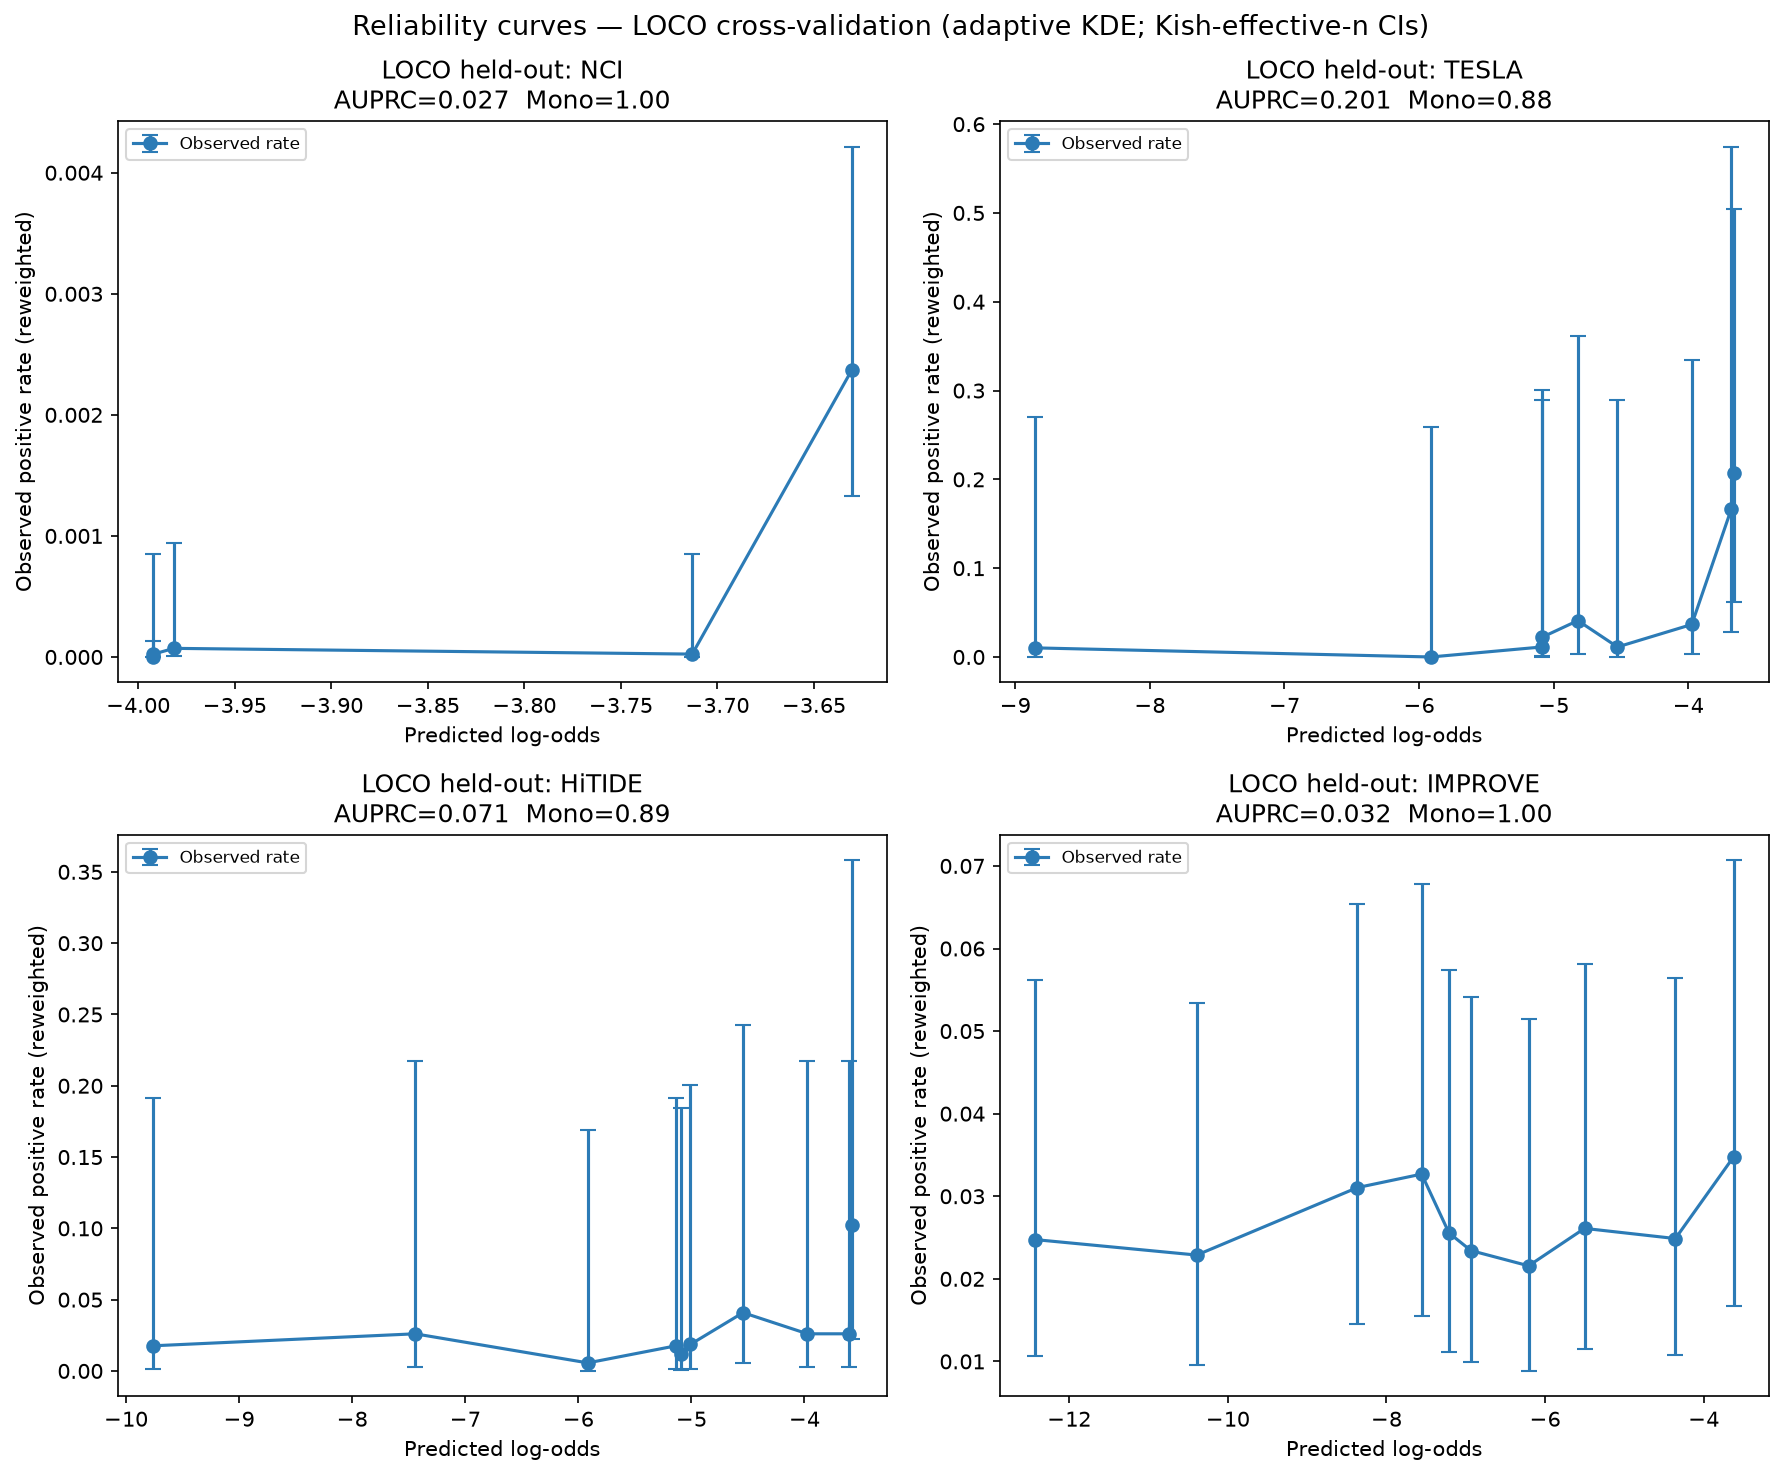

Saved monotonicity.png


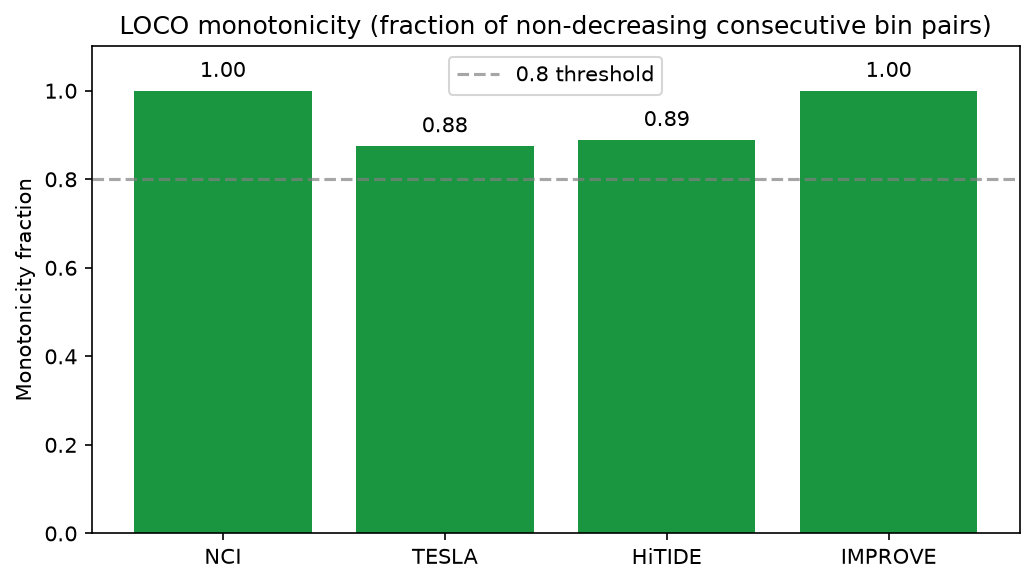

Saved shift_gap.png


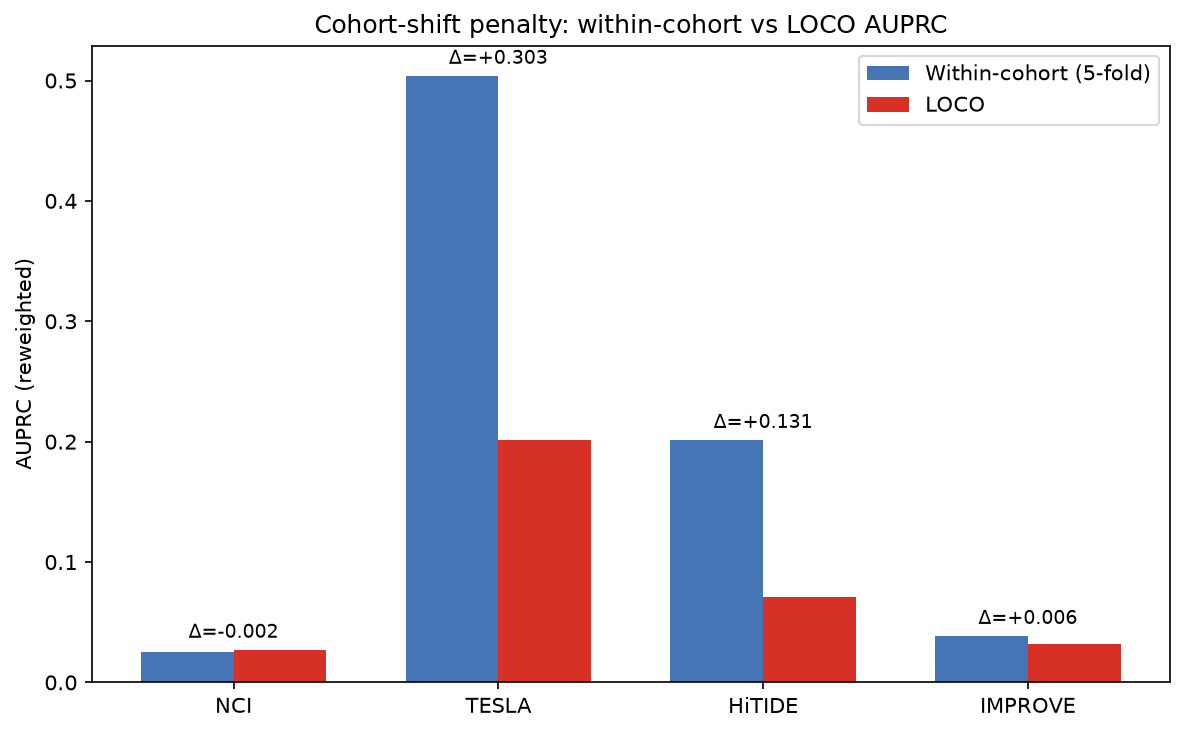

Saved kde_compare.png


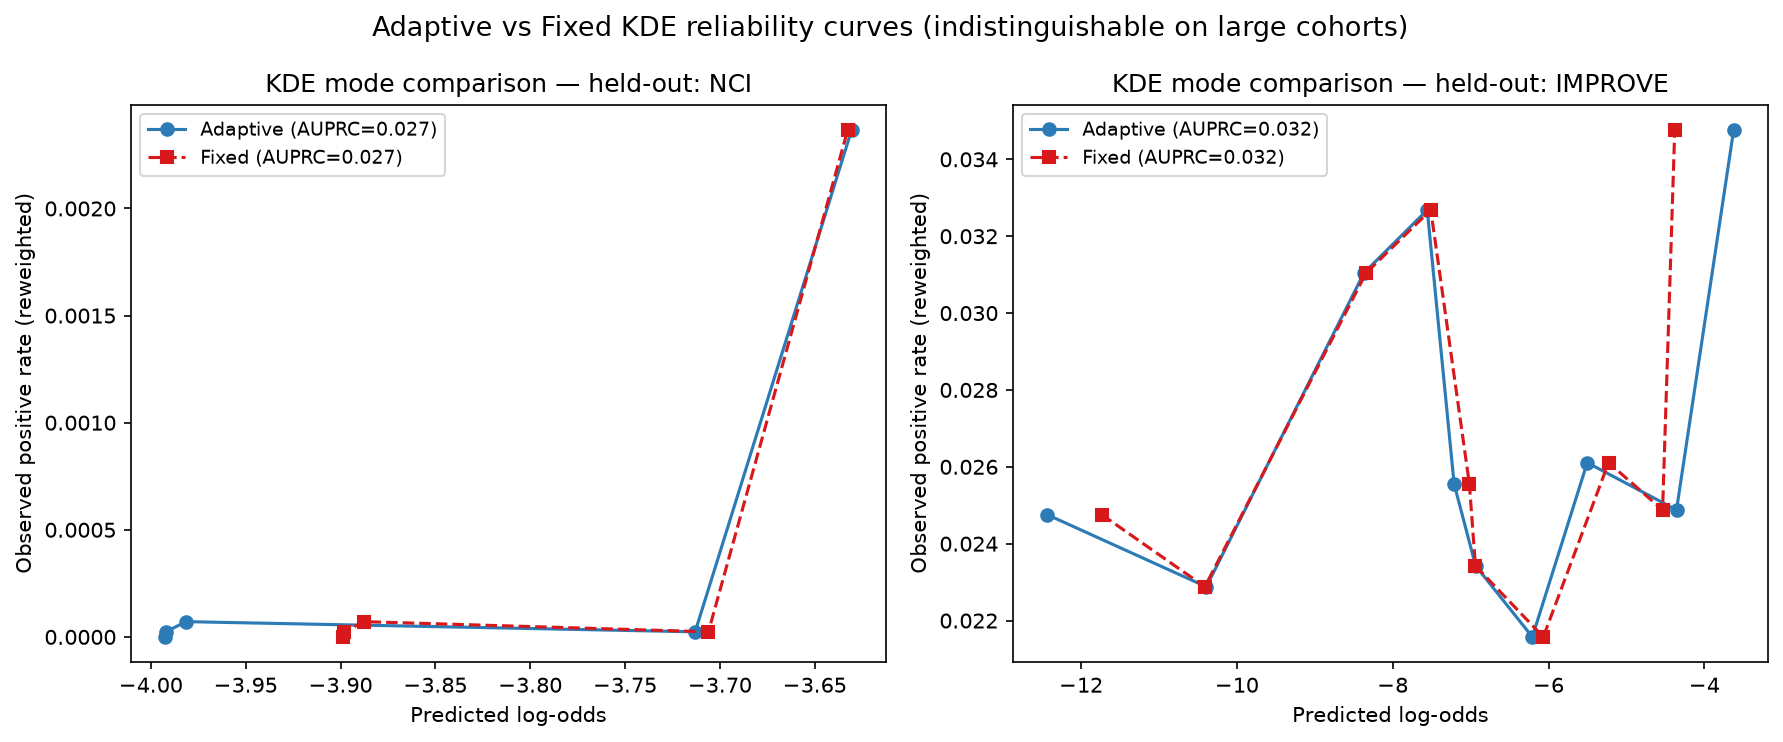


KDE note: mean delta=-0.0124 driven by TESLA (n_pos=34); artifact uses adaptive (AC-specified).


In [8]:
import os
from IPython.display import display, Image
out_dir = os.path.join(BASE, "outputs")

# Each figure is saved to outputs/*.png AND embedded inline below via
# display(Image(...)) — reading back the saved PNG so the rendered notebook is
# self-contained and the inline image is byte-identical to the saved file.
# (matplotlib uses the Agg backend, so display(fig) alone would not emit a PNG.)

# --- Figure 1: PR reliability curves (LOCO, adaptive) ---
# Note: CIs are now wider than before — Kish effective n corrects for reweighting variance.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, res in zip(axes, loco_results):
    rc = res["rc"]
    ax.errorbar(
        rc["bin_mid"], rc["obs_rate"],
        yerr=[rc["obs_rate"] - rc["ci_lo"], rc["ci_hi"] - rc["obs_rate"]],
        fmt="o-", color="#2c7bb6", capsize=4, label="Observed rate"
    )
    ax.set_xlabel("Predicted log-odds")
    ax.set_ylabel("Observed positive rate (reweighted)")
    ax.set_title(f"LOCO held-out: {res['held_out']}\nAUPRC={res['auprc']:.3f}  Mono={res['monotonicity']:.2f}")
    ax.legend(fontsize=8)
plt.suptitle("Reliability curves — LOCO cross-validation (adaptive KDE; Kish-effective-n CIs)", fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(out_dir, "pr_reliability.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved pr_reliability.png")
display(Image(filename=os.path.join(out_dir, "pr_reliability.png")))

# --- Figure 2: Monotonicity (bar chart) ---
fig, ax = plt.subplots(figsize=(7, 4))
mono_vals = [r["monotonicity"] for r in loco_results]
cohort_labels = [r["held_out"] for r in loco_results]
bars = ax.bar(cohort_labels, mono_vals, color=["#1a9641" if v >= 0.8 else "#fdae61" for v in mono_vals])
ax.set_ylabel("Monotonicity fraction")
ax.set_ylim(0, 1.1)
ax.axhline(0.8, ls="--", color="gray", alpha=0.7, label="0.8 threshold")
ax.set_title("LOCO monotonicity (fraction of non-decreasing consecutive bin pairs)")
ax.legend()
for bar, v in zip(bars, mono_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "monotonicity.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved monotonicity.png")
display(Image(filename=os.path.join(out_dir, "monotonicity.png")))

# --- Figure 3: Shift gap (within vs LOCO AUPRC) ---
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(within_df))
width = 0.35
b1 = ax.bar(x - width/2, within_df["within_auprc"], width, label="Within-cohort (5-fold)", color="#4575b4")
b2 = ax.bar(x + width/2, within_df["loco_auprc"], width, label="LOCO", color="#d73027")
ax.set_xticks(x)
ax.set_xticklabels(within_df["cohort"])
ax.set_ylabel("AUPRC (reweighted)")
ax.set_title("Cohort-shift penalty: within-cohort vs LOCO AUPRC")
ax.legend()
for i, row in within_df.iterrows():
    gap = row["shift_gap"]
    ax.text(i, max(row["within_auprc"], row["loco_auprc"]) + 0.01, f"Δ={gap:+.3f}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "shift_gap.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved shift_gap.png")
display(Image(filename=os.path.join(out_dir, "shift_gap.png")))

# --- Figure 4: KDE mode comparison (overlay reliability for NCI and IMPROVE) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cohort in zip(axes, ["NCI", "IMPROVE"]):
    res_a = next(r for r in kde_compare["adaptive"] if r["held_out"] == cohort)
    res_f = next(r for r in kde_compare["fixed"] if r["held_out"] == cohort)
    rc_a, rc_f = res_a["rc"], res_f["rc"]
    ax.plot(rc_a["bin_mid"], rc_a["obs_rate"], "o-", label=f"Adaptive (AUPRC={res_a['auprc']:.3f})", color="#2c7bb6")
    ax.plot(rc_f["bin_mid"], rc_f["obs_rate"], "s--", label=f"Fixed (AUPRC={res_f['auprc']:.3f})", color="#d7191c")
    ax.set_xlabel("Predicted log-odds")
    ax.set_ylabel("Observed positive rate (reweighted)")
    ax.set_title(f"KDE mode comparison — held-out: {cohort}")
    ax.legend(fontsize=9)
plt.suptitle("Adaptive vs Fixed KDE reliability curves (indistinguishable on large cohorts)", fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(out_dir, "kde_compare.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved kde_compare.png")
display(Image(filename=os.path.join(out_dir, "kde_compare.png")))
print(f"\nKDE note: mean delta={kde_comp_df['delta'].mean():.4f} driven by TESLA (n_pos=34); artifact uses adaptive (AC-specified).")

Fit the final calibrator on all four cohorts using full true counts and save the artifact.

In [9]:
all_scores = df["genotype_presentation_score"].values
all_labels = df["label"].values
n_pos_all = sum(true_pos[c] for c in COHORTS)
n_neg_all = sum(true_neg[c] for c in COHORTS)

print(f"Final fit: all cohorts={COHORTS}")
print(f"  true n_pos={n_pos_all}, true n_neg={n_neg_all}")
print(f"  prior = log({n_pos_all}/{n_neg_all}) = {np.log(n_pos_all/n_neg_all):.4f}")

cal_final = PresentationCalibrator(kde_mode=winner_kde, n_grid=512)
cal_final.fit(all_scores, all_labels,
              n_pos_true=n_pos_all, n_neg_true=n_neg_all,
              fit_cohorts=COHORTS)

save_path = os.path.join(BASE, "outputs/calibrator_v1.joblib")
cal_final.save(save_path)
print(f"\nSaved: {save_path}")
print(f"  kde_mode: {cal_final.kde_mode}")
print(f"  prior_: {cal_final.prior_:.4f}")
print(f"  score_range_: {cal_final.score_range_}")
print(f"  n_knots: {len(cal_final.cx_)}")
print(f"  fit_cohorts_: {cal_final.fit_cohorts_}")

# Sanity check: monotone on a grid
grid_check = np.linspace(0, 1, 20)
lo_grid = cal_final.transform(grid_check)
diffs = np.diff(lo_grid)
n_viol = int((diffs < -1e-10).sum())
print(f"\nSanity: {n_viol} monotonicity violations on 20-point [0,1] grid (expected 0)")
print("  log-odds at [0, 0.25, 0.5, 0.75, 1.0]:", cal_final.transform(np.array([0,0.25,0.5,0.75,1.0])).round(4).tolist())

Final fit: all cohorts=['NCI', 'TESLA', 'HiTIDE', 'IMPROVE']
  true n_pos=645, true n_neg=439960
  prior = log(645/439960) = -6.5252



Saved: /Users/jin-holee/dev/GitHub/Jin-HoMLee/splice-neoepitope-pipeline-scientist/research/experiments/issue_547_immunogenicity_calibration/outputs/calibrator_v1.joblib
  kde_mode: adaptive
  prior_: -6.5252
  score_range_: (0.002158, 0.999999)
  n_knots: 401
  fit_cohorts_: ['NCI', 'TESLA', 'HiTIDE', 'IMPROVE']

Sanity: 0 monotonicity violations on 20-point [0,1] grid (expected 0)
  log-odds at [0, 0.25, 0.5, 0.75, 1.0]: [-9.7094, -5.5708, -5.0705, -4.5358, -3.5206]
